###   Крутки

In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import time


%matplotlib inline

In [2]:
#  Число экспериментов
n_exp = 50000

Warranty_hero_1 = 75
Warranty_hero_2 = 90

base_hero_prob = 0.006
base_weapon_prob = 0.01

Warranty_weapon_1 = 65
Warranty_weapon_2 = 80

after_increase_hero_prob = 0.3238 # c 76
after_increase_weapon_prob = 0.2526 # c 66

print("avarega hero: ", 1.5 / 0.016)
print("avarega weapon: ", 1.25 / 0.02)

avarega hero:  93.75
avarega weapon:  62.5


In [3]:
def generate_hero_prob_arr():
    arr = []
    sum_prob = 0
    for roll in range(1, 76):
        sum_prob += base_hero_prob*(1-sum_prob)
        arr.append(sum_prob)

    for roll in range(76, 90):
        sum_prob += after_increase_hero_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)
    
def generate_hero_prob_arr_from(start):
    start+=1
    arr = []
    sum_prob = 0
    if start < 76:
        for roll in range(start, 76):
            sum_prob += base_hero_prob*(1-sum_prob)
            arr.append(sum_prob)
        start = 76

    for roll in range(start, 90):
        sum_prob += after_increase_hero_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)
    
def generate_weapon_prob_arr():
    arr = []
    sum_prob = 0
    for roll in range(1, 66):
        sum_prob += base_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)

    for roll in range(66, 80):
        sum_prob += after_increase_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)

def generate_weapon_prob_arr_from(start):
    start+=1
    arr = []
    sum_prob = 0
    if start < 66:
        for roll in range(start, 66):
            sum_prob += base_weapon_prob*(1-sum_prob)
            arr.append(sum_prob)
        start = 66

    for roll in range(start, 80):
        sum_prob += after_increase_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)

def find_index(arr, prob):
    return np.searchsorted(arr, prob, side="right") + 1
    for i in range(len(arr)):
        if arr[i] > prob:
            return i + 1
    return len(arr)

def find_index_fast(arr, prob):
    return np.searchsorted(arr, prob, side="right") + 1
    
hero_prob_arr = generate_hero_prob_arr()
weapon_prob_arr = generate_weapon_prob_arr()
weapon_sample = [0, 1, 1, 1]

### 1 эксперимент подсчета круток на ивентового 5* героя

In [4]:
def get_event_hero_exp_from(hero_prob_arr_from, hard_warranty):
    roll = find_index(hero_prob_arr_from, random.random())
    if hard_warranty or random.getrandbits(1):
        return roll
    return roll + find_index(hero_prob_arr, random.random())

def get_event_hero_exp():
    roll = find_index(hero_prob_arr, random.random())
    if random.getrandbits(1):
        return roll
    return roll + find_index(hero_prob_arr, random.random())

### 1 эксперимент подсчета круток на ивентового 5* героя с констами

In [5]:
def get_event_hero(hero_prob_arr_from, hard_warranty = False, count = 1):
    if count == 0:
        return 0
    roll = get_event_hero_exp_from(hero_prob_arr_from, hard_warranty)
    
    for i in range(1, count):
        roll += get_event_hero_exp()
    return roll

### 1 эксперимент подсчета круток на ивентового 5* оружия

In [6]:
def get_event_weapon_exp_from(weapon_prob_arr_from, hard_warranty):
    roll = find_index(weapon_prob_arr_from, random.random())
    if hard_warranty or random.choice(weapon_sample):
        return roll
    return roll + find_index(weapon_prob_arr, random.random())

def get_event_weapon_exp():
    roll = find_index(weapon_prob_arr, random.random())
    if random.choice(weapon_sample):
        return roll
    return roll + find_index(weapon_prob_arr, random.random())

### 1 эксперимент подсчета круток на ивентового 5* оружия с констами

In [7]:
def get_event_weapon(weapon_prob_arr_from, hard_warranty = False, count = 1):
    if count == 0:
        return 0
    roll = get_event_weapon_exp_from(weapon_prob_arr_from, hard_warranty)
    
    for i in range(1, count):
        roll += get_event_weapon_exp()
    return roll

### число роллов для героя и его сигны

In [8]:
def count_roll_for_hero_sign(hard_warranty_hero = False, roll_completed_hero = 0, count_hero = 0,
                             hard_warranty_weapon = False,  roll_completed_weapon = 0, count_weapon = 0):
    res = np.empty(n_exp)
    hero_prob_arr_from = hero_prob_arr if roll_completed_hero == 0 else generate_hero_prob_arr_from(roll_completed_hero)
    weapon_prob_arr_from = weapon_prob_arr if roll_completed_weapon == 0 else generate_weapon_prob_arr_from(roll_completed_weapon)
    for i in range(n_exp):
        res[i] = (get_event_hero(hero_prob_arr_from, hard_warranty_hero, count_hero)
            + get_event_weapon(weapon_prob_arr_from, hard_warranty_weapon, count_weapon))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### число роллов для героя

In [9]:
def count_roll_for_hero(hard_warranty = False, roll_completed = 0, count = 0):
    res = np.empty(n_exp)
    hero_prob_arr_from = hero_prob_arr if roll_completed_hero == 0 else generate_hero_prob_arr_from(roll_completed_hero)
    for i in range(n_exp):
        res[i] = get_event_hero(hero_prob_arr_from, hard_warranty, count)

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### Мой скам

In [10]:
def scum_func(count_hero, count_weapon):
    res = np.empty(n_exp)
    hero_prob_arr_from = hero_prob_arr
    weapon_prob_arr_from = weapon_prob_arr
    for i in range(n_exp):
        res[i] = (get_event_hero(hero_prob_arr_from, False, count_hero)
            + get_event_weapon(weapon_prob_arr_from, False, count_weapon))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

In [11]:
# main 33 + 20

start_time = time.time()
q, frame, w = scum_func(count_hero = 3, count_weapon = 1)
sorted = frame.sort_values(by=[0])
end_time = time.time()
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,238.000
0.200,273.000
0.400,322.000
0.500,343.000
0.550,354.000
0.600,366.000
0.650,377.000
0.700,387.000
0.750,399.000
0.800,415.000


In [12]:
print("--- %s seconds ---" % (end_time - start_time))

--- 0.5321199893951416 seconds ---


In [13]:
# main
luck_coef = len(sorted[sorted[0] <= 457])/50000
print(f"{luck_coef:.4%} людей удачливее вас")

91.3040% людей удачливее вас


### Персонаж + Оружие

In [20]:
q, frame, w = count_roll_for_hero_sign(hard_warranty_hero = True, roll_completed_hero = 28, count_hero = 3,
                                       hard_warranty_weapon = False,  roll_completed_weapon = 9, count_weapon = 0)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

# 122 (132) в начале
# 167 (181) в середине
# 212 (235) в конце

,0
0.100,149.0
0.200,177.0
0.400,210.0
0.500,227.0
0.550,238.0
0.600,248.0
0.650,259.0
0.700,270.0
0.750,280.0
0.800,284.0


In [21]:
sorted = frame.sort_values(by=[0])

In [22]:
len(sorted[sorted[0] <= 325])/50000

0.92578

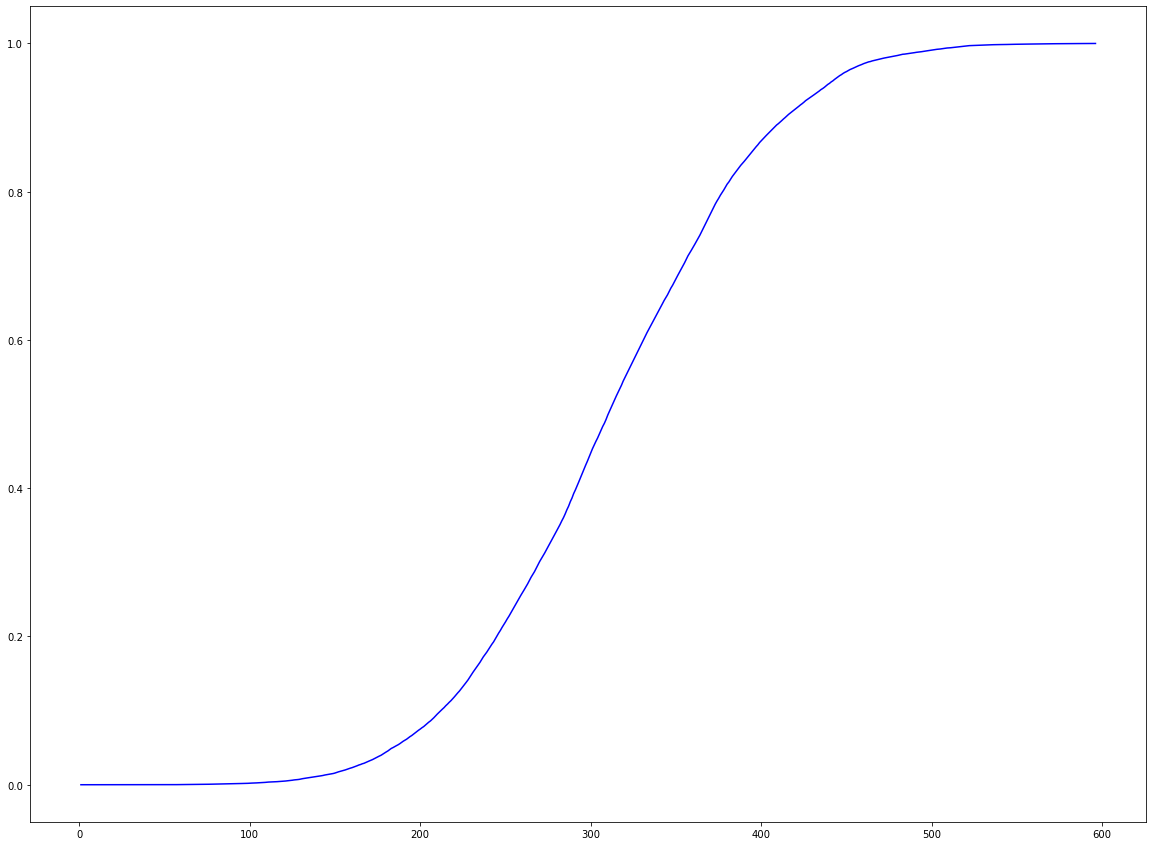

In [49]:
x=[]
y=[]
i = 1
prob = 0
while prob < 1:
    prob = len(sorted[sorted[0] <= i])/50000
    x.append(i)
    y.append(prob)
    i+=1
    

plt.figure(figsize=(20, 15))
plt.plot(x, y, color ='blue')

### Нина

In [50]:
q, frame, w = count_roll_for_hero_sign(False, 0, 1,
                                       False, 0, 1)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,86.0
0.200,107.0
0.400,144.0
0.500,151.0
0.550,157.0
0.600,166.0
0.650,176.0
0.700,186.0
0.750,198.0
0.800,212.0


In [52]:
q, frame, w = count_roll_for_hero_sign(False, 0, 3,
                                       False, 0, 1)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,239.0
0.200,273.0
0.400,321.0
0.500,343.0
0.550,355.0
0.600,366.0
0.650,377.0
0.700,387.0
0.750,399.0
0.800,414.0


In [53]:
q, frame, w = count_roll_for_hero(False, 0, 3)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,184.0
0.200,218.0
0.400,259.0
0.500,282.0
0.550,294.0
0.600,305.0
0.650,311.0
0.700,318.0
0.750,330.0
0.800,345.0
